## Sample code to run the FL models locally

In [1]:
import torch.nn as nn
import numpy as np
import pandas as pd
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset

from shared import SimpleNet, eval_local, train_local, get_initial_arrays

In [2]:
site_prefix = "OBI" # "MGL" #OBI #UOT # BHDC

synth_ds_dir = Path("../../../fed_learning/neuroFL/synthetic_ds") # ../../PD-challenge-ds-store/synthetic_ds/ 
features_subdir = synth_ds_dir / site_prefix / 'features'
labels_subdir = synth_ds_dir  / site_prefix / 'labels'

idp_subdir = features_subdir / 'idp'
mri_subdir = features_subdir / 'bids'
tabular_subdir = features_subdir / 'tabular'

demo_save_file = Path(f"{features_subdir}/tabular/demographics.tsv")
labels_save_file = Path(f"{labels_subdir}/labels.tsv")
idp_save_file = Path(f"{features_subdir}/idp/freesurfer-7.3.2.tsv")

In [3]:
# initialize
input_dim = 134
new_arrays = get_initial_arrays(input_dim, dropout=0.0)

# start the training loop
train_performance = []
eval_performance = []
n_rounds = 5
n_epochs = 50

train_config = {
    "data-path": synth_ds_dir / site_prefix,
    "batch-size": 32,
    "epochs": n_epochs,
    "lr": 1e-2,
    "dropout": 0.0
}

test_config = {
    "data-path": synth_ds_dir / site_prefix,
    "batch-size": 1,
    "dropout": 0.0  
}

for round in range(n_rounds):
    print(f"Round {round+1}")
    new_arrays, num_examples, train_metrics = train_local(new_arrays, train_config, debug=False)
    train_performance.append(train_metrics)

    avg_loss, total, eval_metrics = eval_local(new_arrays, test_config)

    print(f"Evaluation Metrics: {train_metrics}, {eval_metrics}")
    eval_performance.append(eval_metrics)

Round 1


/home/nikhil/projects/my_venvs/synth-ds/lib/python3.12/site-packages/torch/cuda/__init__.py:188: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 9010). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Evaluation Metrics: {'train_loss': 0.0007585118873976171}, {'val_loss': 0.0007290338497114135, 'val_accuracy': 1.0}
Round 2
Evaluation Metrics: {'train_loss': 8.79166748291027e-07}, {'val_loss': 1.162287560774189e-06, 'val_accuracy': 1.0}
Round 3
Evaluation Metrics: {'train_loss': 0.0}, {'val_loss': 0.0, 'val_accuracy': 1.0}
Round 4
Evaluation Metrics: {'train_loss': 0.0}, {'val_loss': 0.0, 'val_accuracy': 1.0}
Round 5
Evaluation Metrics: {'train_loss': 0.0}, {'val_loss': 0.0, 'val_accuracy': 1.0}


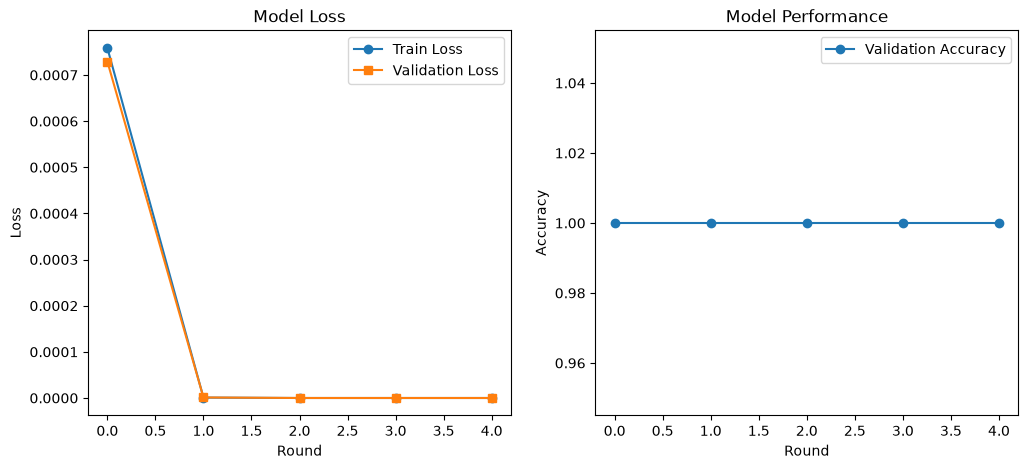

In [4]:
# Plot the evaluation metrics
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Plot train and validation loss
axes[0].plot([x['train_loss'] for x in train_performance], marker='o', label='Train Loss')
axes[0].plot([x['val_loss'] for x in eval_performance], marker='s', label='Validation Loss')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Plot Validation Accuracy
axes[1].plot([x['val_accuracy'] for x in eval_performance], marker='o', label='Validation Accuracy')
axes[1].set_title('Model Performance')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
plt.show()